# 01 — Preprocessing

This notebook loads the raw Sentinel-2 and Sentinel-1 GeoTIFF files exported from Google Earth Engine, checks them for quality, resamples the Sentinel-2 20m bands to 10m resolution, and saves clean processed versions ready for feature engineering.

**Inputs:** Raw GeoTIFFs in GEOL0069/Project/Data  
**Outputs:** Processed GeoTIFFs in GEOL0069/Project/Data/Processed

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Install rasterio — the main library for reading and writing geospatial raster data
!pip install rasterio --quiet

import rasterio
from rasterio.enums import Resampling
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries loaded successfully")
print(f"Rasterio version: {rasterio.__version__}")

Libraries loaded successfully
Rasterio version: 1.5.0


In [3]:
data_path = '/content/drive/MyDrive/GEOL0069/Project/Data'
processed_path = '/content/drive/MyDrive/GEOL0069/Project/Data/Processed'

# Create the Processed subfolder if it doesn't exist yet
os.makedirs(processed_path, exist_ok=True)

epochs = ['2019', '2021', '2023', '2025']

print(f"Data folder: {data_path}")
print(f"Processed folder: {processed_path}")

Data folder: /content/drive/MyDrive/GEOL0069/Project/Data
Processed folder: /content/drive/MyDrive/GEOL0069/Project/Data/Processed


Before doing anything else we read each file and print its basic properties: number of bands, pixel dimensions, coordinate reference system, and value range. This is just a sanity check to confirm the GEE exports worked properly.


In [4]:
# Check each Sentinel-2 file
print("=== SENTINEL-2 FILES ===\n")

for epoch in epochs:
    filepath = os.path.join(data_path, f'S2_{epoch}_cambridge.tif')

    with rasterio.open(filepath) as src:
        print(f"Epoch: {epoch}")
        print(f"  Bands: {src.count}")
        print(f"  Dimensions: {src.width} x {src.height} pixels")
        print(f"  CRS: {src.crs}")
        print(f"  Resolution: {src.res[0]}m x {src.res[1]}m")

        # Read first band to check value range
        band1 = src.read(1)
        valid = band1[band1 > 0]  # exclude nodata pixels
        if len(valid) > 0:
            print(f"  Value range (band 1): {valid.min():.4f} — {valid.max():.4f}")
        print()

=== SENTINEL-2 FILES ===

Epoch: 2019
  Bands: 10
  Dimensions: 3212 x 3465 pixels
  CRS: EPSG:32630
  Resolution: 10.0m x 10.0m
  Value range (band 1): 0.0135 — 0.9196

Epoch: 2021
  Bands: 10
  Dimensions: 3212 x 3465 pixels
  CRS: EPSG:32630
  Resolution: 10.0m x 10.0m
  Value range (band 1): 0.0001 — 1.4212

Epoch: 2023
  Bands: 10
  Dimensions: 3212 x 3465 pixels
  CRS: EPSG:32630
  Resolution: 10.0m x 10.0m
  Value range (band 1): 0.0000 — 2.0672

Epoch: 2025
  Bands: 10
  Dimensions: 3212 x 3465 pixels
  CRS: EPSG:32630
  Resolution: 10.0m x 10.0m
  Value range (band 1): 0.0011 — 0.8024



In [5]:
# Check each Sentinel-1 file
print("=== SENTINEL-1 FILES ===\n")

for epoch in epochs:
    filepath = os.path.join(data_path, f'S1_{epoch}_cambridge.tif')

    with rasterio.open(filepath) as src:
        print(f"Epoch: {epoch}")
        print(f"  Bands: {src.count}")
        print(f"  Dimensions: {src.width} x {src.height} pixels")
        print(f"  CRS: {src.crs}")
        print(f"  Resolution: {src.res[0]}m x {src.res[1]}m")

        # Read VV band (band 1) to check value range
        vv = src.read(1)
        valid = vv[np.isfinite(vv)]
        if len(valid) > 0:
            print(f"  VV value range: {valid.min():.2f} — {valid.max():.2f} dB")
        print()

=== SENTINEL-1 FILES ===

Epoch: 2019
  Bands: 2
  Dimensions: 3212 x 3465 pixels
  CRS: EPSG:32630
  Resolution: 10.0m x 10.0m
  VV value range: -25.90 — 22.29 dB

Epoch: 2021
  Bands: 2
  Dimensions: 3212 x 3465 pixels
  CRS: EPSG:32630
  Resolution: 10.0m x 10.0m
  VV value range: -23.93 — 22.66 dB

Epoch: 2023
  Bands: 2
  Dimensions: 3212 x 3465 pixels
  CRS: EPSG:32630
  Resolution: 10.0m x 10.0m
  VV value range: -25.69 — 24.92 dB

Epoch: 2025
  Bands: 2
  Dimensions: 3212 x 3465 pixels
  CRS: EPSG:32630
  Resolution: 10.0m x 10.0m
  VV value range: -26.10 — 23.88 dB



Before processing anything, it is good practice to look at the actual imagery. Here we plot a true colour (RGB) image for each epoch using Sentinel-2 bands B4 (red), B3 (green), B2 (blue). This lets us visually confirm the study area looks correct and check for obvious cloud contamination.


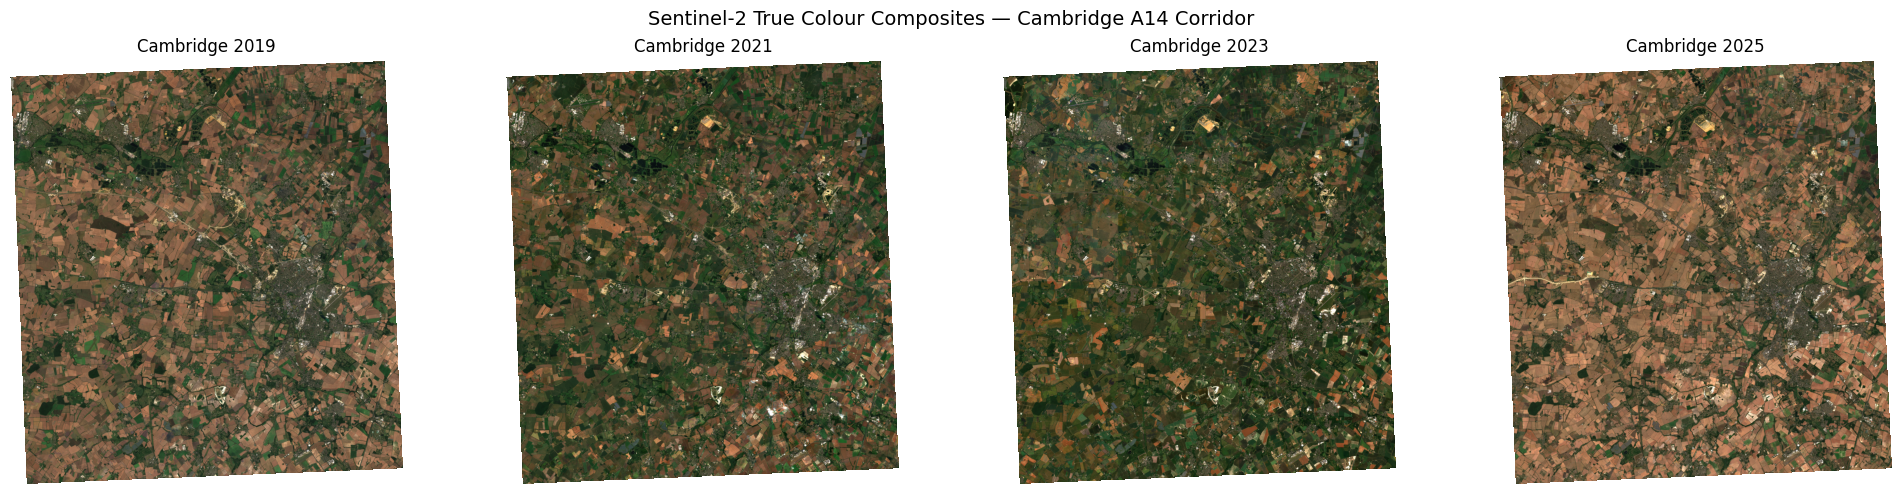

Figure saved to Processed folder


In [6]:
def make_rgb(filepath, brightness=3.5):
    """
    Reads Sentinel-2 bands B4, B3, B2 and returns a displayable RGB array.
    Brightness factor increases visibility — S2 reflectance values are small.
    """
    with rasterio.open(filepath) as src:
        # Band order in our export: B2=1, B3=2, B4=3, B5=4, B6=5, B7=6, B8=7, B8A=8, B11=9, B12=10
        red   = src.read(3).astype(float)  # B4
        green = src.read(2).astype(float)  # B3
        blue  = src.read(1).astype(float)  # B2

    rgb = np.dstack([red, green, blue])
    rgb = np.clip(rgb * brightness, 0, 1)
    return rgb

# Plot all four epochs side by side
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, epoch in zip(axes, epochs):
    filepath = os.path.join(data_path, f'S2_{epoch}_cambridge.tif')
    rgb = make_rgb(filepath)
    ax.imshow(rgb)
    ax.set_title(f'Cambridge {epoch}', fontsize=12)
    ax.axis('off')

plt.suptitle('Sentinel-2 True Colour Composites — Cambridge A14 Corridor', fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(processed_path, 'true_colour_composites.png'), dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved to Processed folder")

Our Sentinel-2 export contains bands at two different resolutions. Bands B2, B3, B4, B8 are natively 10m. Bands B5, B6, B7, B8A, B11, B12 are natively 20m. For our feature stack later, we need all bands at the same 10m resolution so every pixel has a complete set of values.

We use bilinear resampling, which is the standard approach for continuous data like reflectance values — it interpolates smooth

In [7]:
def resample_to_10m(filepath, output_path):
    """
    Reads a Sentinel-2 GeoTIFF and resamples all bands to 10m resolution.
    Saves the result as a new GeoTIFF in the output path.
    """
    with rasterio.open(filepath) as src:

        # Calculate new dimensions at 10m resolution
        scale_factor = src.res[0] / 10.0
        new_height = int(src.height * scale_factor)
        new_width  = int(src.width  * scale_factor)

        # Read all bands resampled to new dimensions
        data = src.read(
            out_shape=(src.count, new_height, new_width),
            resampling=Resampling.bilinear
        )

        # Update the metadata to reflect new resolution and dimensions
        new_transform = src.transform * src.transform.scale(
            src.width  / new_width,
            src.height / new_height
        )

        new_meta = src.meta.copy()
        new_meta.update({
            'height': new_height,
            'width':  new_width,
            'transform': new_transform,
            'dtype': 'float32'
        })

        # Write to output file
        with rasterio.open(output_path, 'w', **new_meta) as dst:
            dst.write(data.astype('float32'))

    return new_height, new_width


# Resample all four Sentinel-2 epochs
print("Resampling Sentinel-2 bands to 10m...\n")

for epoch in epochs:
    input_path  = os.path.join(data_path, f'S2_{epoch}_cambridge.tif')
    output_path = os.path.join(processed_path, f'S2_{epoch}_10m.tif')

    h, w = resample_to_10m(input_path, output_path)
    print(f"  {epoch}: done — output dimensions {w} x {h} pixels at 10m")

print("\nAll Sentinel-2 files resampled and saved")

Resampling Sentinel-2 bands to 10m...

  2019: done — output dimensions 3212 x 3465 pixels at 10m
  2021: done — output dimensions 3212 x 3465 pixels at 10m
  2023: done — output dimensions 3212 x 3465 pixels at 10m
  2025: done — output dimensions 3212 x 3465 pixels at 10m

All Sentinel-2 files resampled and saved


Sentinel-1 values are in decibels (dB), which is a logarithmic scale. We convert them to linear scale (power units) for the feature engineering stage, as most machine learning algorithms perform better with linearly scaled inputs. We also clip any extreme outlier values which occasionally appear at scene edges.


In [8]:
def process_s1(filepath, output_path):
    """
    Reads Sentinel-1 GeoTIFF, converts from dB to linear power scale,
    clips outliers, and saves a clean version.
    """
    with rasterio.open(filepath) as src:
        data = src.read().astype('float32')  # shape: (2, height, width) — VV and VH
        meta = src.meta.copy()

    # Convert from dB to linear: power = 10^(dB/10)
    # Replace any non-finite values with 0 first
    data = np.where(np.isfinite(data), data, 0)
    data_linear = np.power(10, data / 10.0)

    # Clip to reasonable range (removes edge artefacts)
    data_linear = np.clip(data_linear, 0, np.percentile(data_linear[data_linear > 0], 99))

    meta.update({'dtype': 'float32'})

    with rasterio.open(output_path, 'w', **meta) as dst:
        dst.write(data_linear)


# Process all four Sentinel-1 epochs
print("Processing Sentinel-1 SAR files...\n")

for epoch in epochs:
    input_path  = os.path.join(data_path, f'S1_{epoch}_cambridge.tif')
    output_path = os.path.join(processed_path, f'S1_{epoch}_processed.tif')

    process_s1(input_path, output_path)

    # Quick check on output values
    with rasterio.open(output_path) as src:
        vv = src.read(1)
        valid = vv[vv > 0]
        print(f"  {epoch}: done — VV linear range: {valid.min():.4f} — {valid.max():.4f}")

print("\nAll Sentinel-1 files processed and saved")

Processing Sentinel-1 SAR files...

  2019: done — VV linear range: 0.0026 — 1.0000
  2021: done — VV linear range: 0.0041 — 1.0000
  2023: done — VV linear range: 0.0027 — 1.0000
  2025: done — VV linear range: 0.0025 — 1.0000

All Sentinel-1 files processed and saved


Confirm all processed files exist and have consistent dimensions across epochs. Consistent dimensions are important — if the files are different sizes the feature stacking in notebook 02 will fail.


In [9]:
print("=== PROCESSED FILES CHECK ===\n")

s2_dims = []
s1_dims = []

for epoch in epochs:
    s2_path = os.path.join(processed_path, f'S2_{epoch}_10m.tif')
    s1_path = os.path.join(processed_path, f'S1_{epoch}_processed.tif')

    with rasterio.open(s2_path) as src:
        s2_dims.append((src.width, src.height))
        print(f"S2_{epoch}_10m.tif — {src.width}x{src.height}, {src.count} bands, {src.res[0]}m res")

    with rasterio.open(s1_path) as src:
        s1_dims.append((src.width, src.height))
        print(f"S1_{epoch}_processed.tif — {src.width}x{src.height}, {src.count} bands")

    print()

# Check dimensions are consistent
if len(set(s2_dims)) == 1:
    print("All Sentinel-2 files have consistent dimensions")
else:
    print("WARNING: Sentinel-2 files have inconsistent dimensions — check exports")

if len(set(s1_dims)) == 1:
    print("All Sentinel-1 files have consistent dimensions")
else:
    print("WARNING: Sentinel-1 files have inconsistent dimensions — check exports")

print("\nPreprocessing complete. Ready for notebook 02 — feature engineering.")

=== PROCESSED FILES CHECK ===

S2_2019_10m.tif — 3212x3465, 10 bands, 10.0m res
S1_2019_processed.tif — 3212x3465, 2 bands

S2_2021_10m.tif — 3212x3465, 10 bands, 10.0m res
S1_2021_processed.tif — 3212x3465, 2 bands

S2_2023_10m.tif — 3212x3465, 10 bands, 10.0m res
S1_2023_processed.tif — 3212x3465, 2 bands

S2_2025_10m.tif — 3212x3465, 10 bands, 10.0m res
S1_2025_processed.tif — 3212x3465, 2 bands

All Sentinel-2 files have consistent dimensions
All Sentinel-1 files have consistent dimensions

Preprocessing complete. Ready for notebook 02 — feature engineering.
